# bagelR "daily" example

## Install bagelR

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/RtmplRpLkn/remotes33791d7208b8/grosed-bagel-d9b2a6b/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.6.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.6.0’

## Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




## Define the feature vector function 

In [4]:
feature_vector_daily <- function(t,tau)
{
  if(tau==0){
    M <- matrix(c(0),nc=1,nr=7)
    M[1,1] <- 1
    M[t%%7+1,1] <- 1
  }else{
    M <- matrix(c(0),nc=1,nr=8)
    M[1,1] <- 1
    M[t%%7+1,1] <- 1
    if(t>tau){
      M[8,1] <- 1
    }
  }
  return(M)
}



## Define the prior function

In [5]:
prior_daily <- function(t){
  if(t==1){
    mu <- matrix(rep(0,7),nc=1,nr=7)
    sigma <- diag(c(10,rep(1,6)))
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(rep(0,8),nc=1,nr=8)
  sigma <- diag(c(10,rep(1,7)))
  return(list("mu" = mu,"sigma" = sigma))
  }

## Define the transform function

In [6]:
transform_daily <- function(tau)
{
  return(matrix(c(1,0,0,0,0,0,0,1),1,8,byrow=TRUE))
}

## Generate the data

In [7]:
set.seed(1)

In [8]:
set.seed(1)

Y <- rnorm(1000,0,1)
for(j in 1:6){
  daily.effect <- rnorm(1)
  Y[j+7*(0:142)] <- Y[j+7*(0:142)] +daily.effect
}
Y[901:1000]<-Y[901:1000]+1

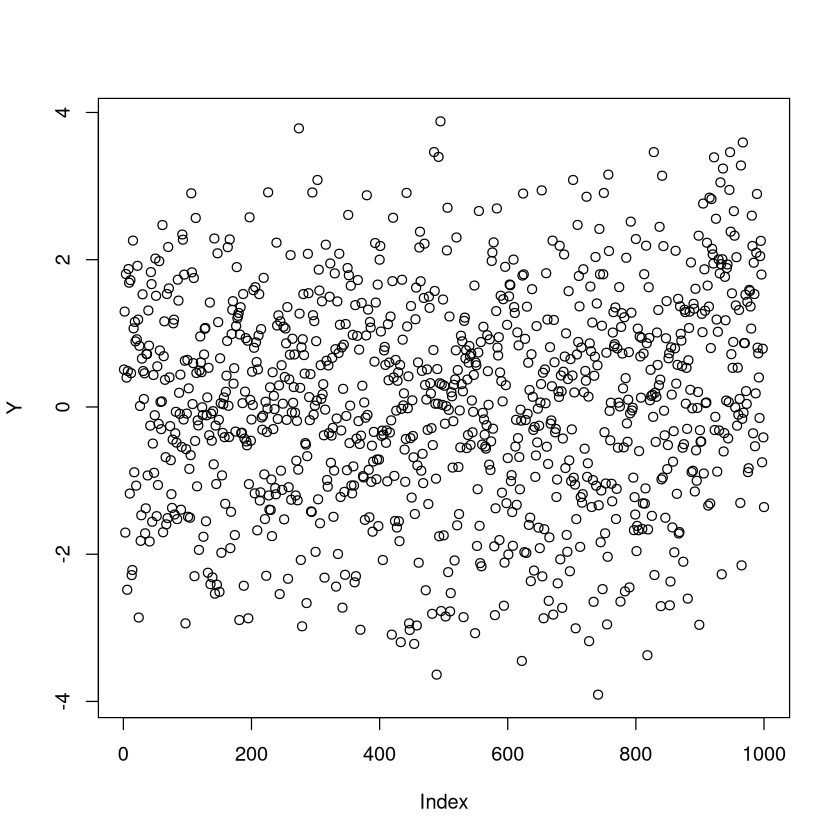

In [9]:
plot(Y)

## Set model parameters 

In [10]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

## Offline analysis - known variance

**Note** - _approximate_ variation used since analysis is _multivariate_ 

In [11]:
results <- bagel_kv_approximate(Y,feature_vector_daily,prior_daily,transform_daily,p0,p,noise_sd,max_particles,threshold)

## Check for a changepoint

In [12]:
changepoint(results)

$location
[1] 901

$detected
[1] 921

## Visualise weight at tau = 0

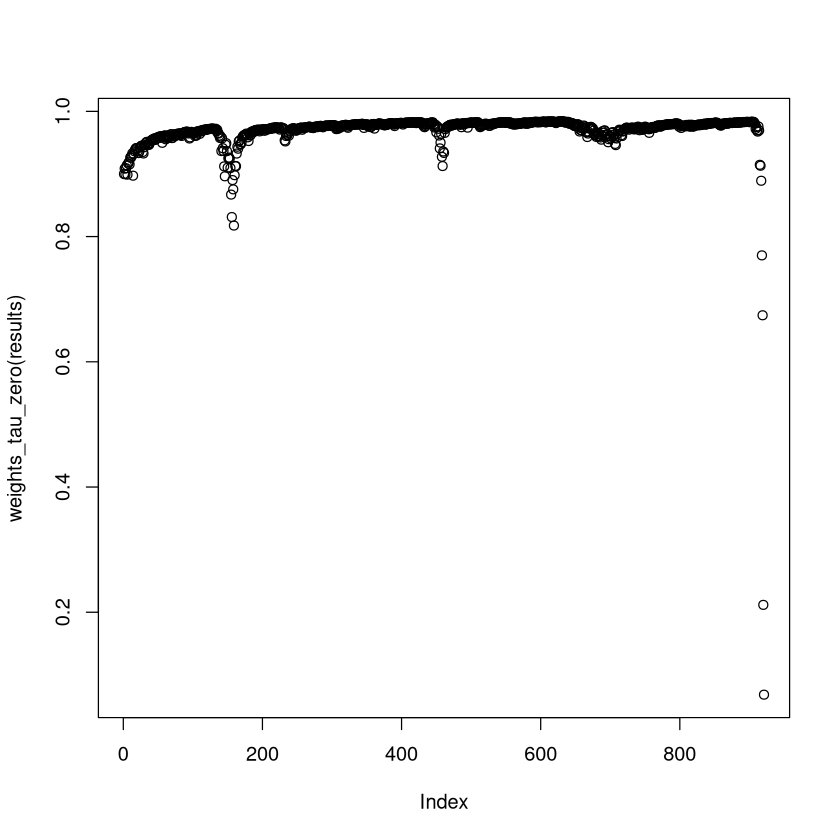

In [13]:
plot(weights_tau_zero(results))

## Visualise the weights of the active particles

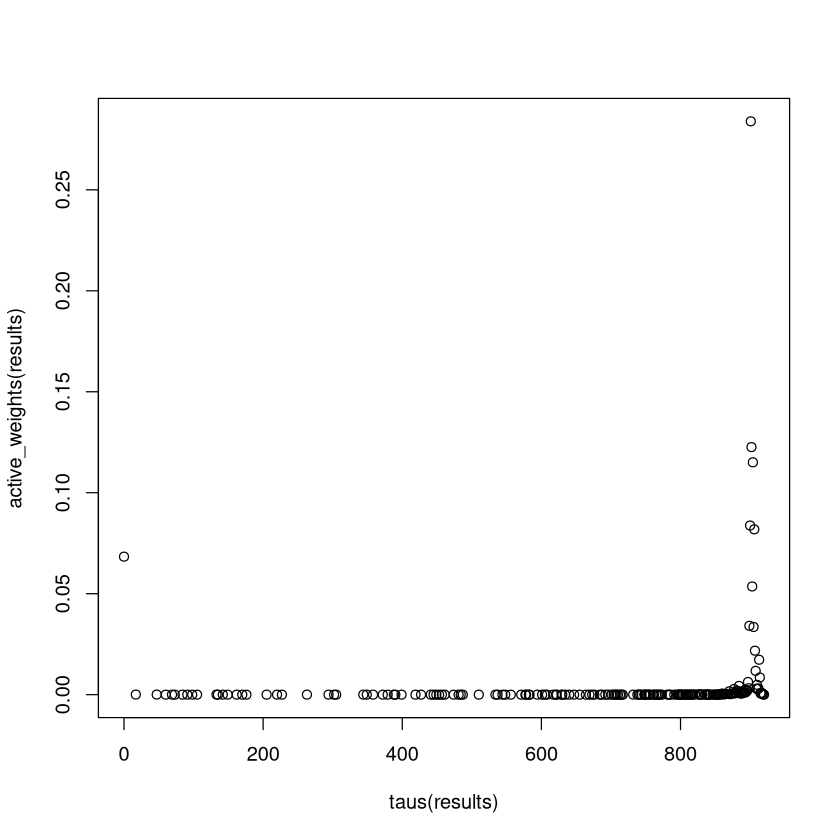

In [14]:
plot(taus(results),active_weights(results))

## Plot weights in region of changepoint

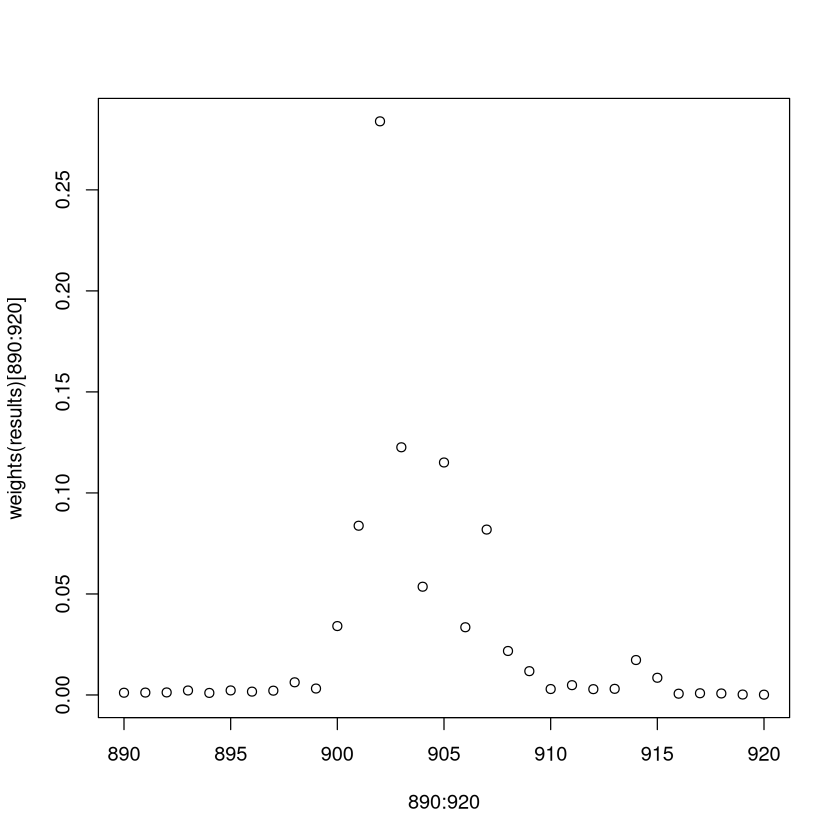

In [15]:
plot(890:920,weights(results)[890:920])